# 7. Choosing and Tuning an Algorithm

Every chapter so far has used a random forest, chosen by fiat. This chapter asks whether that was right, and then asks whether its default settings were right.

The answers are instructive: a plain logistic regression beats it, and tuning it recovers less accuracy than the tuning process's own optimism inflates.

**You will learn:**

- how to search a catalog of 189 components instead of guessing
- how to run a fair bake-off across algorithm families
- what hyperparameters an algorithm has, without reading its source
- `GridSearchCV` and `RandomSearchCV`, and why random search wins in high dimensions
- why the score your tuner reports is not a score you may report

**Prerequisites:** chapters 2 and 4.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tuiml.datasets import load_diabetes
from tuiml.preprocessing import SimpleImputer, StandardScaler
from tuiml.workflow import Workflow
from tuiml.evaluation import cross_val_score, StratifiedKFold

data = load_diabetes()
y = data.y

X = data.X.copy()
for name in ["plas", "pres", "skin", "insu", "mass"]:
    col = data.feature_names.index(name)
    X[X[:, col] == 0, col] = np.nan
X = SimpleImputer(strategy="median").fit_transform(X)

splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
print(X.shape)

(768, 8)


## 7.1 Finding candidates

Chapter 0 introduced the discovery API. This is what it is for: you do not memorise class names, you ask.

In [2]:
import tuiml

print("classifiers available:", len(tuiml.list_algorithms("classifier")))
print()
for hit in tuiml.search_algorithms("rule", limit=6):
    print(f"  {hit['name']:28s} {hit['type']}")

classifiers available: 89

  M5ModelRulesRegressor        regressor
  OneRuleClassifier            classifier
  ZeroRuleClassifier           classifier
  AprioriAssociator            associator
  ECLATAssociator              associator
  FPGrowthAssociator           associator


`describe_algorithm` gives you the full parameter schema, which is how you find out what is tunable before you tune it:

In [3]:
info = tuiml.describe_algorithm("RandomForestClassifier")

for param, meta in info["parameters"].items():
    default = meta.get("default")
    description = (meta.get("description") or "")[:46]
    print(f"  {param:20s} default={str(default):8s} {description}")

  n_estimators         default=100      Number of trees in the forest
  max_features         default=sqrt     Number of features to consider at each split
  max_depth            default=None     Maximum depth of trees
  min_samples_split    default=2        Minimum samples required to split a node
  min_samples_leaf     default=1        Minimum samples required at a leaf node
  bootstrap            default=True     Whether to use bootstrap samples
  oob_score            default=False    Whether to calculate out-of-bag score
  random_state         default=None     Random seed for reproducibility
  n_jobs               default=1        Number of parallel jobs (-1 for all CPUs)
  criterion            default=gini     Splitting criterion


## 7.2 A bake-off

The reliable way to choose an algorithm is to try several. One representative from each family, all on identical folds, all preceded by the same scaling step so that the distance-based candidates get a fair hearing:

In [4]:
from tuiml.algorithms.rules import ZeroRuleClassifier, OneRuleClassifier
from tuiml.algorithms.bayesian import NaiveBayesClassifier
from tuiml.algorithms.linear import LogisticRegression
from tuiml.algorithms.neighbors import KNearestNeighborsClassifier
from tuiml.algorithms.svm import SVC
from tuiml.algorithms.trees import DecisionTreeClassifier, RandomForestClassifier

candidates = {
    "ZeroRule (baseline)": ZeroRuleClassifier(),
    "OneRule": OneRuleClassifier(),
    "Naive Bayes": NaiveBayesClassifier(),
    "Logistic regression": LogisticRegression(),
    "k-nearest neighbours": KNearestNeighborsClassifier(k=5),
    "SVC": SVC(),
    "Decision tree": DecisionTreeClassifier(random_state=42),
    "Random forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

results = {}
for label, model in candidates.items():
    results[label] = cross_val_score(
        Workflow([StandardScaler(), model]), X, y, cv=splitter
    ).mean()

for label, score in sorted(results.items(), key=lambda kv: -kv[1]):
    bar = "#" * int((score - 0.6) * 200)
    print(f"  {label:22s} {score:.4f}  {bar}")

  Logistic regression    0.7772  ###################################
  Random forest          0.7630  ################################
  SVC                    0.7552  ###############################
  Naive Bayes            0.7473  #############################
  k-nearest neighbours   0.7331  ##########################
  OneRule                0.6992  ###################
  Decision tree          0.6966  ###################
  ZeroRule (baseline)    0.6511  ##########


Three things in that ranking are worth more than the ranking itself.

**Logistic regression wins.** The simplest model that is not a baseline beats a 200-tree ensemble. With eight numeric features and a fairly linear relationship between glucose and outcome, there is not much non-linear structure for the forest to find, and the forest pays for its flexibility in variance.

**`ZeroRuleClassifier` reproduces the 0.65 we have been quoting since chapter 1**, which is the point of having it in the catalog — the baseline is a model you run, not a number you remember.

**`OneRuleClassifier` is close behind the decision tree.** OneRule builds a single rule on a single feature. That it lands within a few points of models with thousands of parameters tells you most of the signal here is "glucose is high", and that should temper expectations for everything that follows.

> **Remark — try the simple thing first.** Not as a moral position, but because on tabular data with few features it frequently wins, and when it does not, it gives you the number that everything else has to beat.

## 7.3 Hyperparameters

Every algorithm has settings that are not learned from the data. A forest's `n_estimators`, a tree's `max_depth`, KNN's `k`. Defaults are reasonable guesses, not answers.

You can see an algorithm's settings without leaving the notebook:

In [5]:
forest = RandomForestClassifier()
print(forest.get_params())

{'n_estimators': 100, 'max_features': 'sqrt', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': True, 'oob_score': False, 'random_state': None, 'n_jobs': -1, 'criterion': 'gini'}


Two of these matter a great deal for a forest, and they pull in opposite directions. `max_depth` limits how far each tree may split — deeper trees fit the training data more closely and generalise less. `min_samples_leaf` sets how many rows a leaf must contain, which is the same trade from the other side.

Watch the trade happen:

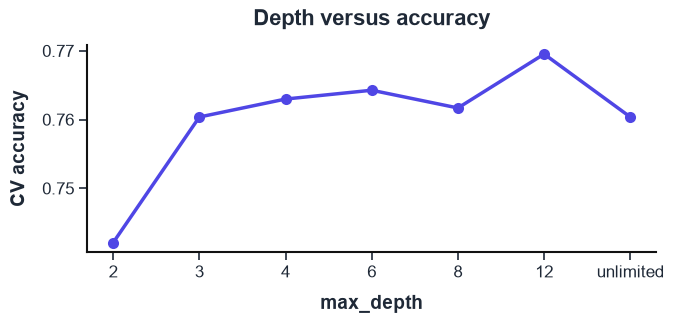

  max_depth=2         0.7421
  max_depth=3         0.7604
  max_depth=4         0.7630
  max_depth=6         0.7643
  max_depth=8         0.7617
  max_depth=12        0.7695
  max_depth=unlimited 0.7604


In [6]:
depths = [2, 3, 4, 6, 8, 12, None]
depth_scores = [
    cross_val_score(
        Workflow([RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)]),
        X, y, cv=splitter,
    ).mean()
    for d in depths
]

fig, ax = plt.subplots(figsize=(7, 3.4))
labels = [str(d) if d is not None else "unlimited" for d in depths]
ax.plot(range(len(depths)), depth_scores, marker="o", color="#4f46e5")
ax.set_xticks(range(len(depths)))
ax.set_xticklabels(labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("CV accuracy")
ax.set_title("Depth versus accuracy")
plt.show()

for d, s in zip(labels, depth_scores):
    print(f"  max_depth={d:9s} {s:.4f}")

## 7.4 Grid search

`GridSearchCV` tries every combination in a grid, scoring each with its own cross-validation, and keeps the best.

In [7]:
from tuiml.evaluation import GridSearchCV

grid = {
    "n_estimators": [50, 200],
    "max_depth": [3, 6, None],
    "min_samples_leaf": [1, 5],
}

search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    grid,
    cv=5,
    scoring="accuracy",
    random_seed=42,
)
search.fit(X, y)

result = search.get_results()
print("best parameters:", result.best_params)
print(f"best score     : {result.best_score:.4f}")
print(f"configurations : {len(result.cv_results['params'])}")

best parameters: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1}
best score     : 0.7734
configurations : 12


The grid had 2 × 3 × 2 = 12 combinations, each cross-validated 5 ways: 60 model fits to move the score by a few thousandths.

Note which parameters won — essentially the defaults. This is common and not a failure of the search; it means the library's defaults were well chosen for data of this shape.

## 7.5 Random search

Grid search has a scaling problem. Add a fourth parameter with four values and you are at 96 combinations; a fifth takes you past 400. Worse, the grid spends its budget uniformly, including on parameters that turn out not to matter.

`RandomSearchCV` samples combinations instead. For the same budget it tries more distinct values of *each* parameter, which is what you want when — as is usually the case — only two or three of them actually matter.

In [8]:
from tuiml.evaluation import RandomSearchCV

distributions = {
    "n_estimators": [50, 100, 150, 200, 300],
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf": [1, 2, 3, 5, 8],
    "max_features": ["sqrt", "log2", None],
}

random_search = RandomSearchCV(
    RandomForestClassifier(random_state=42),
    distributions,
    n_iter=15,
    cv=5,
    scoring="accuracy",
    random_seed=42,
)
random_search.fit(X, y)

random_result = random_search.get_results()
print("best parameters:", random_result.best_params)
print(f"best score     : {random_result.best_score:.4f}")
print(f"configurations : {random_result.n_iterations} of "
      f"{5 * 7 * 5 * 3} possible")

best parameters: {'n_estimators': np.int64(200), 'max_depth': None, 'min_samples_leaf': np.int64(3), 'max_features': 'sqrt'}
best score     : 0.7773
configurations : 15 of 525 possible


15 samples out of 525 possible combinations, and it lands in the same territory as the exhaustive grid. That ratio is the argument: **when the budget is fixed, random beats grid**, and the advantage grows with the number of parameters.

## 7.6 The score your tuner reports is not your score

Now the part that matters more than either search.

`best_score` above is the highest score among the configurations tried. It was selected by *maximising over the same cross-validation you are now quoting* — which is the chapter 2 mistake wearing a very respectable suit. Try twelve configurations, keep the luckiest, and its score includes the luck.

The fix is **nested cross-validation**: an outer loop that holds data back, and an inner loop that does the entire tuning process on the remaining data. The outer fold never participates in choosing anything.

In [9]:
from tuiml.evaluation import accuracy_score

outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
nested_scores = []

for train_idx, test_idx in outer.split(X, y):
    inner_search = GridSearchCV(
        RandomForestClassifier(random_state=42), grid,
        cv=5, scoring="accuracy", random_seed=42,
    )
    inner_search.fit(X[train_idx], y[train_idx])          # tuning sees train only
    nested_scores.append(accuracy_score(y[test_idx], inner_search.predict(X[test_idx])))

nested = np.mean(nested_scores)
untuned = cross_val_score(
    Workflow([RandomForestClassifier(n_estimators=200, random_state=42)]),
    X, y, cv=splitter,
).mean()

print(f"untuned forest                    : {untuned:.4f}")
print(f"nested CV, tuned (honest)         : {nested:.4f}")
print(f"grid search's own best_score      : {result.best_score:.4f}")
print()
print(f"real gain from tuning             : {nested - untuned:+.4f}")
print(f"optimism in the reported best_score: {result.best_score - nested:+.4f}")

untuned forest                    : 0.7669
nested CV, tuned (honest)         : 0.7695
grid search's own best_score      : 0.7734

real gain from tuning             : +0.0026
optimism in the reported best_score: +0.0039


Read the last two lines together. Tuning bought a small genuine improvement — and the number the tuner printed overstates the tuned model by *more than the improvement was worth*. Quote `best_score` in a report and you have claimed a gain that is mostly an artefact of having gone looking for one.

> **Remark — this is not an argument against tuning.** It is an argument for knowing which number to publish. Use the search to *choose* the configuration; use nested CV, or a test set held back and touched exactly once, to *report* it.

Nested CV costs the outer fold count times more compute. When that is too expensive, the practical alternative is a three-way split — train, validation, test — where you tune against validation and touch the test set once, at the end, after every decision has been made.

## 7.7 Tuning as a spec

The declarative API takes the same job:

```python
tuiml.train({
    "model": {"name": "RandomForestClassifier"},
    "data": "diabetes",
    "evaluation": {"cv": 10},
    "random_seed": 42,
})
```

and the MCP tool `tuiml_tune` exposes the search to an agent, which is chapter 11's territory. The lesson of section 7.6 does not change when the tuning is done by a language model — if anything it gets sharper, because an agent will happily try fifty configurations and report the best one with great confidence.

## Recap

- Search the catalog rather than recalling class names: `list_algorithms`, `search_algorithms`, `describe_algorithm`.
- Run a bake-off across families on identical folds. Here **logistic regression beat a 200-tree forest**.
- `ZeroRuleClassifier` gives you the baseline as a model; `OneRuleClassifier` tells you how much of the signal one feature carries.
- Hyperparameters are not learned from data. `get_params()` lists them; `describe_algorithm` documents them.
- `GridSearchCV` is exhaustive; `RandomSearchCV` samples, and wins at fixed budget once you have more than two or three parameters.
- **`best_score` is optimistically biased.** Here the bias exceeded the entire gain from tuning.
- Use the search to choose; use nested CV or a once-touched test set to report.

**Next:** chapter 8 compares many models at once and answers the question this chapter kept deferring — when is the gap between two scores real, and when is it noise?